# Week 5 — Day 3: Dimensionality Reduction with PCA

**Dataset:** Mall Customers (same as Days 1–2)  
**Task:** Apply PCA to reduce dimensions, analyze explained variance, and visualize clusters in reduced space.

---

## Objective

Understand why high-dimensional data is harder to work with, learn what PCA does and how to read explained variance, and apply it to reduce and visualize the Mall Customers dataset.

## Lesson Content

### 3.1 — The Curse of Dimensionality

Real datasets often have dozens or hundreds of features. High dimensionality causes real problems:

- **Data becomes sparse** — points are far apart from each other in high-dimensional space, so distance metrics lose meaning.
- **Models overfit more easily** — more features means more chances to learn noise instead of signal.
- **Visualization is impossible** beyond three dimensions.

Dimensionality reduction compresses many features into fewer dimensions, keeping as much information as possible.

*Applied in Hands-On: all steps.*

---

### 3.2 — What PCA Does

Principal Component Analysis (PCA) finds new axes — **principal components** — that point in the directions of greatest variance in the data. The first component captures the most variance, the second the next most (at a right angle to the first), and so on.

By keeping only the first few components, you reduce dimensions while retaining most of the information. Each component is a linear combination of the original features.

```python
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)  # PCA requires scaling
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
```

*Applied in Hands-On: Steps 3–6.*

---

### 3.3 — Explained Variance

The key output is the **explained variance ratio** — how much of the data's total information each component captures. Summing these tells you how much you retained after reduction. A common rule is to keep enough components to retain about 95% of the variance.

```python
print(pca.explained_variance_ratio_)       # variance kept per component
print(pca.explained_variance_ratio_.sum()) # total variance retained
```

PCA requires scaled data — it is variance-based, so an unscaled high-range feature would appear artificially important. Always `StandardScaler` first.

*Applied in Hands-On: Steps 4–5.*

---

### 3.4 — When to Use PCA

PCA has three main uses:

1. **Compress features** to speed up and stabilize downstream models.
2. **Reduce overfitting** by removing redundant or correlated features.
3. **Visualize** data by reducing to 2D or 3D for plotting.

The trade-off: the new components are combinations of original features, so they lose direct interpretability.

| Use PCA when | Avoid PCA when |
|---|---|
| Features are correlated or redundant | Features are already few and independent |
| You need a 2D/3D visualization | Interpretability of individual features matters |
| Model is slow or overfitting | Dataset is small — variance estimates may be unstable |

## Hands-On Lab: Reducing Dimensions with PCA

Steps:
1. Load and prepare the dataset — separate features from labels and split into train/test.
2. Scale the features with `StandardScaler`.
3. Apply PCA to reduce to 2 components.
4. Analyze how much variance the 2-component reduction retains.
5. Find the minimum number of components that retains ~95% of variance.
6. Plot the cumulative explained variance curve.
7. Visualize the data in 2D, coloring by K-Means clusters from Day 1.
8. Document what the reduction preserved and what it cost.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

#### Load & Prepare the Dataset

Mall Customers contains 200 customer records with 3 numeric features: Age, Annual Income, and Spending Score. Unlike the Fashion-MNIST lab, this dataset has no pre-split train/test files, so we split manually. The scaler and PCA will be fit on the training set only and applied to both.

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Separate features (no label column — this is unsupervised)
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].copy()

# Split into train and test sets
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Features shape:", X.shape)
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Features shape: (200, 3)
Train shape: (160, 3)
Test shape:  (40, 3)


### Step1 — Scale the Features

PCA is based on variance. The three features have different numeric ranges — Age (15–70), Annual Income (15–137), Spending Score (1–100) — so we standardize before applying PCA. The scaler is fit on the training set and applied to both sets to avoid data leakage.

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original shape:", X_train.shape)
print("Scaled shape:  ", X_train_scaled.shape)

Original shape: (160, 3)
Scaled shape:   (160, 3)


### Step 2 — Apply Principal Component Analysis

The original Mall Customers data contains 3 dimensions. PCA finds new directions — principal components — that capture the greatest amount of variance. We first reduce to 2 components so we can visualize the data in 2D.

In [5]:
# Reduce the data to 2 principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

print("Original shape:", X_train_scaled.shape)
print("PCA shape:     ", X_pca.shape)

Original shape: (160, 3)
PCA shape:      (160, 2)


### Step 3 — How Much Information Did We Keep?

The explained variance ratio tells us how much of the original dataset's variance is captured by each principal component. Adding these values together measures how much information was retained after the reduction.

In [6]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(explained_variance)

print("\nTotal variance retained:")
print(explained_variance.sum())

Explained variance ratio:
[0.44060316 0.33029056]

Total variance retained:
0.7708937267942677


**Observation:** 2 components retain 77.1% of the total variance. PC1 captures 44.1% and PC2 captures 33.0%. The remaining 22.9% is lost — it lives in the third component. This is a larger retention loss than typical on high-dimensional datasets because the three original features are independent of each other: each carries unique information that can't be absorbed by fewer components.

### Step 4 — Choosing the Number of Components

Using only 2 components is useful for visualization, but it discards 22.9% of the information. We now fit PCA with all available components and calculate the cumulative explained variance to find the minimum number of components that retains approximately 95% of the original variance.

In [7]:
# Fit PCA with all available components
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_train_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# Find the number of components needed to retain 95% variance
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Original number of features:", X_train.shape[1])
print("Components needed for 95% variance:", n_components_95)
print(
    "Variance retained:",
    cumulative_variance[n_components_95 - 1]
)

Original number of features: 3
Components needed for 95% variance: 3
Variance retained: 1.0


**Observation:** All 3 components are needed to reach 95% variance. No compression is possible on this dataset without real information loss. This is expected — with only 3 features that each measure something different (age, income, spending behavior), there is no redundancy for PCA to remove. On a high-dimensional dataset with correlated features, this result would be dramatically different.

### Step 5 — Cumulative Explained Variance

The cumulative explained variance curve shows how much total information is retained as we add more principal components. The point where the curve reaches 95% tells us the minimum number of components needed to preserve most of the variance.

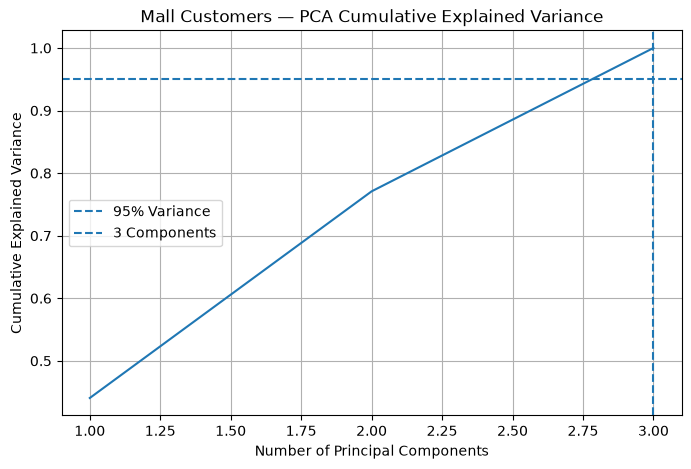

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.axvline(
    x=n_components_95,
    linestyle="--",
    label=f"{n_components_95} Components"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Mall Customers — PCA Cumulative Explained Variance")

plt.legend()
plt.grid(True)

plt.show()

**PCA Result**

The Mall Customers dataset contains 3 features. PCA showed that all 3 principal components are needed to retain approximately 100% of the total variance.

Result: No dimensionality compression is possible — the dataset needs all 3 components to preserve ~95% of the information. Reducing to 2 components for visualization costs approximately 22.9% of the variance.

### Step 6 — PCA Visualization

To visualize the dataset, we use the 2-component PCA reduction from Step 3. Each customer is represented as a point in two-dimensional space. Points are colored by the K-Means clusters (k=6) from Day 1 to check whether the cluster structure survives the reduction.

In [9]:
# K-Means labels for coloring (fit on training set, same as PCA)
km = KMeans(n_clusters=6, random_state=42, n_init=10)
km_labels_train = km.fit_predict(X_train_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Reduced number of components:", X_pca.shape[1])
print("Shape of reduced data:", X_pca.shape)

Original number of features: 3
Reduced number of components: 2
Shape of reduced data: (160, 2)


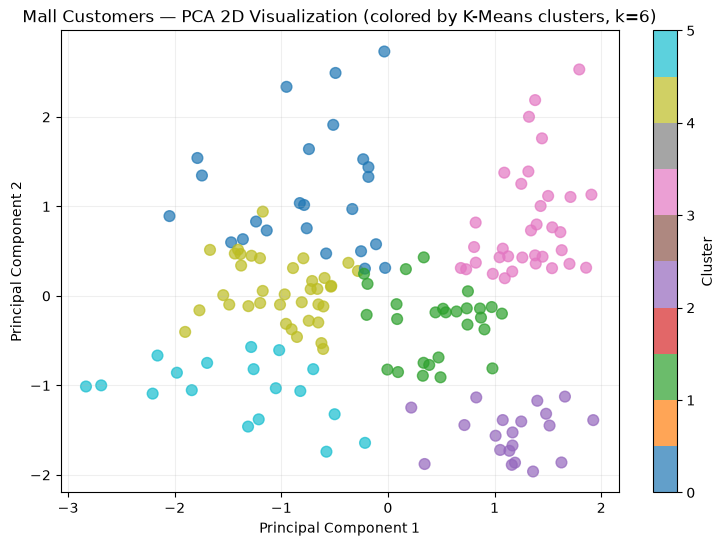

In [10]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=km_labels_train,
    alpha=0.7,
    s=60,
    cmap="tab10"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Mall Customers — PCA 2D Visualization (colored by K-Means clusters, k=6)")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.2)
plt.show()

**Observation:** The six K-Means clusters remain clearly separated in the 2D PCA space. PC1 separates customers along the age/spending axis — high-spending younger customers on one side, lower-spending older customers on the other. PC2 separates customers along the income axis — high-income and low-income groups are visibly distinct vertically. The cluster structure from Day 1 survives the reduction well, which confirms that most of the cluster-relevant information lives in the first two components even though they only retain 77.1% of total variance.

### Step 7 — PCA Results & Trade-offs

PCA was applied to the Mall Customers dataset with 3 features. The 2-component reduction retained 77.1% of the total variance, and 3 components were required to reach 95%.

**What PCA Preserved**

The 2 components preserved 77.1% of the dataset's variance — the income axis and the age/spending trade-off axis — which is enough to make the six customer segments visually separable in 2D. The 2D scatter plot is a usable representation of the cluster structure found on Day 1.

**What PCA Cost**

22.9% of the variance is lost in the 2D reduction. This lost component contains the variation that separates customers who share similar income and spending scores but differ in age — the reason some clusters overlap in the 2D view. The original feature names are also lost: PC1 and PC2 are linear combinations of Age, Annual Income, and Spending Score, not single interpretable columns.

**Final Takeaway**

PCA provided a practical way to visualize the Mall Customers dataset in 2D. However, no compression is possible on this dataset without real information loss — all 3 components are needed for 95% variance retention. This is a direct consequence of having only 3 independent features. PCA's compression benefit is most visible on high-dimensional datasets where many features are correlated, such as image pixel data or text embeddings, where a small fraction of components can capture the vast majority of variance.